# Test CBD torques to ensure smooth behaviour around equilibrium eccentricity

In [1]:
import holodeck as holo
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from holodeck import utils, cosmo
from holodeck import plot as hplot
import holodeck.accretion
from holodeck.constants import MSOL, PC, YR, MPC, GYR, MYR
import seaborn as sns

holo.log.setLevel(holo.log.INFO)

<frozen importlib._bootstrap>:219: RuntimeWarning: compiletime version 3.7 of module 'holodeck.discrete_cyutils' does not match runtime version 3.8
<frozen importlib._bootstrap>:219: RuntimeWarning: builtins.type size changed, may indicate binary incompatibility. Expected 864 from C header, got 880 from PyObject


In [2]:
ECCEN_INIT = 0.01
F_EDD = 0.1
nsteps = 1000
NSELECT = 1
cfl = 0.1

pop = holo.population.Pop_Illustris(select=NSELECT)
size = pop.size
eccen = np.ones(size) * ECCEN_INIT
pop = holo.population.Pop_Illustris(eccen=eccen, select=NSELECT)

qb = 0.7
eb = ECCEN_INIT
mb = 1.e8 * MSOL
m1 = 1/(1+qb) * mb
m2 = qb/(1+qb) * mb
sepa = 0.5 * PC

pop = holo.population.Pop_Illustris(select=NSELECT)
size = pop.size
eccen = np.ones(size) * ECCEN_INIT
pop = holo.population.Pop_Illustris(eccen=eccen, \
    select=NSELECT)
pop.sepa = [sepa]
pop.mass = np.array([[m1,m2]])


hards = [
    holo.hardening.Hard_GW,
    holo.hardening.CBD_Torques(allow_softening=True),
    holo.hardening.Sesana_Scattering(),
    # holo.hardening.Dynamical_Friction_NFW(attenuate=True),
]

hards_no_ses = [
    holo.hardening.Hard_GW,
    holo.hardening.CBD_Torques(allow_softening=True),
    #holo.hardening.Sesana_Scattering(),
    # holo.hardening.Dynamical_Friction_NFW(attenuate=True),
]

acc = holo.accretion.Accretion(
    accmod='Siwek22', f_edd=F_EDD, subpc=True, evol_mass=False, edd_lim=1.0,
)

evo_nolim = holo.evolution.New_Evolution(pop, hards_no_ses, acc=acc, cfl=cfl, nsteps=nsteps)
evo_nolim.evolve(limit_eb=False)
evo_lim = holo.evolution.New_Evolution(pop, hards, acc=acc, cfl=cfl, nsteps=nsteps)
evo_lim.evolve(limit_eb=False)


=====
WARNING SELECTING ONLY 1 BINARIES FROM DATA
=====


=====
WARNING SELECTING ONLY 1 BINARIES FROM DATA
=====


=====
WARNING SELECTING ONLY 1 BINARIES FROM DATA
=====


=====
WARNING SELECTING ONLY 1 BINARIES FROM DATA
=====



  0%|          | 0/1 [00:00<?, ?it/s]

Expanded arrays 0001 times to 2.00e+03


  0%|          | 0/1 [00:00<?, ?it/s]

Expanded arrays 0001 times to 2.00e+03


evo =  <holodeck.evolution.New_Evolution object at 0x7fa74cce8e20>
label =  nSes
at sub-parsec
evo =  <holodeck.evolution.New_Evolution object at 0x7fa74cce8e80>
label =  ySes
at sub-parsec


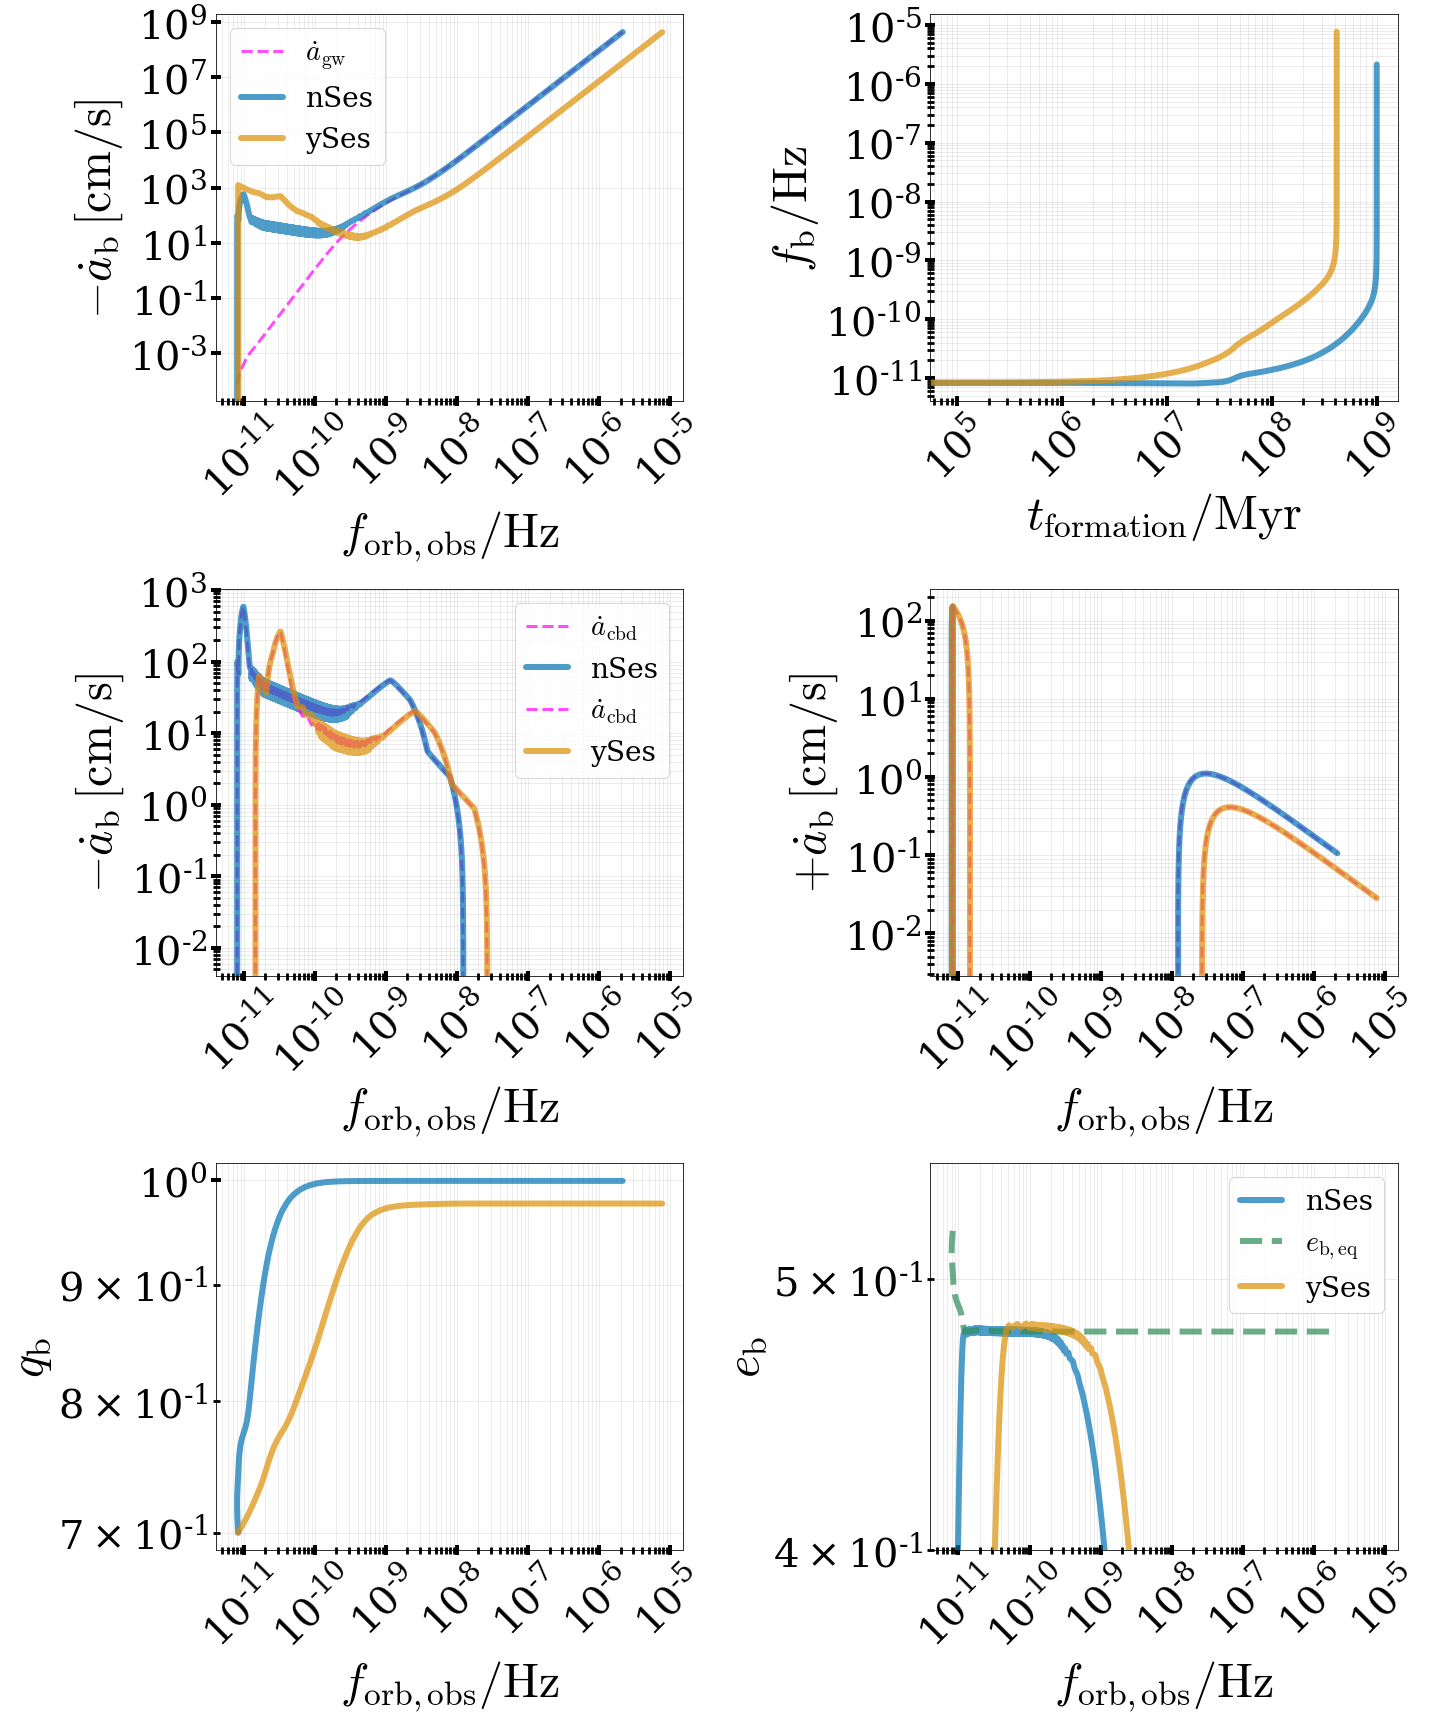

In [3]:
hard_cbd = holo.hardening.CBD_Torques(allow_softening=True)

import seaborn as sns
_AGE_UNIVERSE_GYR = cosmo.age(0.0).to('s').value

fs = 40
lw = 6
figwidth = 10
figheight = 8
ticksize = 10
tickwidth = 4

fig,axes = plt.subplots(3,2, figsize=(2*figwidth,3*figheight))

axes = axes.flatten()

evos = [evo_nolim, evo_lim]
labels = ['nSes', 'ySes']
colors = sns.color_palette('colorblind')
for evo,label,color in zip(evos,labels,colors):
    f_ind = 0
    j = 0
    for k,l_ind in enumerate(evo._last_index):
        print("evo = ", evo)
        print("label = ", label)
        m1 = evo.mass[f_ind:l_ind].T[0]
        m2 = evo.mass[f_ind:l_ind].T[1]
        qb = m2/m1
        if np.any(qb>1):
            qb[qb>1] = 1./qb[qb>1]
        t = evo.tlook[f_ind:l_ind]
        sepa = evo.sepa[f_ind:l_ind]
        mtot = (m1+m2)/MSOL
        eccen = evo.eccen[f_ind:l_ind]
        mdot = np.sum(evo.mdot[f_ind:l_ind],axis=-1)
        redz = cosmo.tage_to_z(_AGE_UNIVERSE_GYR - t)
        #print("redz = ", redz)
        frst_orb = utils.kepler_freq_from_sepa(mtot*MSOL, sepa)
        fobs = utils.fobs_from_frst(frst_orb, redz)
        #analytical gw hardening rate
        dadt_gw = -1*utils.gw_hardening_rate_dadt(m1, m2, sepa, eccen=eccen)
        #CBD hardening rate
        swk23 = holo.hardening._Siwek2023()
        dadt_cbd = -1*swk23.dadt(qb, eccen) * sepa * (mdot/(mtot*MSOL))
        #CBD hardening rate from evo
        dadt_evo_cbd = -1*evo.dadt[f_ind:l_ind][:,1]
        #dadt from evo, including all other hardening rates
        dadt_combined_evo = -1*np.sum(evo.dadt[f_ind:l_ind],axis=-1)

        ind_subpc = evo.sepa[f_ind:l_ind] <= 1*PC

        if len(mtot[ind_subpc]) > 1:
            print("at sub-parsec")
            #calculate the time that has passed since binary hit 1 parsec separation
            t_formation = t[ind_subpc][0] - t[ind_subpc]
            #print("np.shape(evo.dadt[f_ind:l_ind]) = ", np.shape(evo.dadt[f_ind:l_ind]))
            #only plot sub-parsec binaries
            if j == 0:
                if label == labels[0]:
                    axes[0].loglog(fobs[ind_subpc], dadt_gw[ind_subpc], '--', label = r'$\dot{a}_{\rm gw}$', color='magenta', alpha = 0.7, linewidth=0.5*lw)
                axes[0].loglog(fobs[ind_subpc], dadt_combined_evo[ind_subpc], label = label, color=color, alpha = 0.7, linewidth=lw)
            else:
                axes[0].loglog(fobs[ind_subpc], dadt_combined_evo[ind_subpc], label = label, color=color, alpha = 0.7, linewidth=lw)
                if label == labels[0]:
                    axes[0].loglog(fobs[ind_subpc], dadt_gw[ind_subpc], '--', color='magenta', alpha = 0.7, linewidth=0.5*lw)
            
            axes[1].loglog(t_formation/YR, fobs[ind_subpc], color=color, alpha=0.7, linewidth=lw)
            
            if j == 0:
                # if label == labels[0]:
                axes[2].loglog(fobs[ind_subpc], dadt_cbd[ind_subpc], '--', label = r'$\dot{a}_{\rm cbd}$', color='magenta', alpha = 0.7, linewidth=0.5*lw)
                axes[2].loglog(fobs[ind_subpc], dadt_evo_cbd[ind_subpc], label = label, color=color, alpha = 0.7, linewidth=lw)
            else:
                axes[2].loglog(fobs[ind_subpc], dadt_evo_cbd[ind_subpc], label = label, color=color, alpha = 0.7, linewidth=lw)
                if label == labels[0]:
                    axes[2].loglog(fobs[ind_subpc], dadt_cbd[ind_subpc], '--', color='magenta', alpha = 0.7, linewidth=0.5*lw)
            
            if j == 0:
                # if label == labels[0]:
                axes[3].loglog(fobs[ind_subpc], -1*dadt_cbd[ind_subpc], '--', label = r'$\dot{a}_{\rm cbd}$', color='magenta', alpha = 0.7, linewidth=0.5*lw)
                axes[3].loglog(fobs[ind_subpc], -1*dadt_evo_cbd[ind_subpc], label = label, color=color, alpha = 0.7, linewidth=lw)
            else:
                axes[3].loglog(fobs[ind_subpc], -1*dadt_evo_cbd[ind_subpc], label = label, color=color, alpha = 0.7, linewidth=lw)
                if label == labels[0]:
                    axes[3].loglog(fobs[ind_subpc], -1*dadt_cbd[ind_subpc], '--', color='magenta', alpha = 0.7, linewidth=0.5*lw)
            
            axes[4].loglog(fobs[ind_subpc], qb[ind_subpc], label = label, color=color, alpha = 0.7, linewidth=lw)
            
            axes[5].loglog(fobs[ind_subpc], eccen[ind_subpc], label = label, color=color, alpha = 0.7, linewidth=lw)
            if evo == evos[0]:
                ebeq = acc.ebeq(qb[ind_subpc])
                axes[5].loglog(fobs[ind_subpc], ebeq, '--', label = r'$e_{\rm b,eq}$', color='seagreen', alpha = 0.7, linewidth=lw)
            
            j += 1

    f_ind = l_ind+1

axes[0].legend(fontsize=0.7*fs)
axes[2].legend(fontsize=0.7*fs)

#axes[0].invert_xaxis()
for ax in axes:
    #ax.invert_xaxis()
    ax.tick_params(axis='both', which='major', direction='inout', size=ticksize, width=tickwidth)
    ax.tick_params(axis='both', which='minor', direction='inout', size=0.7*ticksize, width=0.7*tickwidth)
    ax.grid(which='both', color='k', linestyle='-', linewidth=0.5)
    plt.setp(ax.get_xticklabels(which='both'), fontsize=fs, rotation=45)
    plt.setp(ax.get_yticklabels(which='both'), fontsize=fs)

axes[0].set_ylabel(r'$-\dot{a}_{\rm b}\, [\rm{cm/s}]$', fontsize=1.2*fs)
axes[0].set_xlabel(r'$f_{\rm orb,obs}/\rm{Hz}$', fontsize=1.2*fs)
axes[1].set_xlabel(r'$t_{\rm formation}/\rm{Myr}$', fontsize=1.2*fs)
axes[1].set_ylabel(r'$f_{\rm b}/\rm{Hz}$', fontsize=1.2*fs)

axes[2].set_ylabel(r'$-\dot{a}_{\rm b}\, [\rm{cm/s}]$', fontsize=1.2*fs)
axes[2].set_xlabel(r'$f_{\rm orb,obs}/\rm{Hz}$', fontsize=1.2*fs)

axes[3].set_ylabel(r'$+\dot{a}_{\rm b}\, [\rm{cm/s}]$', fontsize=1.2*fs)
axes[3].set_xlabel(r'$f_{\rm orb,obs}/\rm{Hz}$', fontsize=1.2*fs)

axes[4].set_ylabel(r'$q_{\rm b}$', fontsize=1.2*fs)
axes[4].set_xlabel(r'$f_{\rm orb,obs}/\rm{Hz}$', fontsize=1.2*fs)

axes[5].legend(fontsize=0.7*fs)
axes[5].set_ylabel(r'$e_{\rm b}$', fontsize=1.2*fs)
axes[5].set_xlabel(r'$f_{\rm orb,obs}/\rm{Hz}$', fontsize=1.2*fs)
axes[5].set_ylim([0.4,0.55])


# axes[1].axvline(x = 1, linestyle = '--', alpha = 0.5, linewidth=lw, color='gray')
# axes[1].set_xlim([1.e7,1.e-5])
# axes[2].set_xlabel(r'$t_{\rm look}/\rm{Myr}$', fontsize=1.2*fs)
# axes[2].set_ylabel(r'$a_{\rm b}/\rm{PC}$', fontsize=1.2*fs)
# axes[3].set_xlabel(r'$a_{\rm b}/\rm{PC}$', fontsize=1.2*fs)
# axes[3].set_ylabel(r'$e_{\rm b}$', fontsize=1.2*fs)

plt.tight_layout()
